<a href="https://colab.research.google.com/github/vitor-thompson/Python-para-financas-investimento-e-analise-de-dados./blob/main/redimento_do_portifolio_3_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# --- Configurações Iniciais ---
data_inicial = pd.to_datetime("2025-12-15")
quantidade_cotas_ini_1 = 44.581
#quantidade_cotas_ini_2 = 15.482

# DEFINE O DIA ATUAL AUTOMATICAMENTE
data_final = pd.to_datetime(datetime.now().date())

# --- MODELO PARA NOVAS ADIÇÕES (Copie e cole abaixo) ---
# ("AAAA-MM-DD", "TICKER.SA", QUANTIDADE, PRECO_UNITARIO),
# Use QUANTIDADE positiva para COMPRAS e negativa para VENDAS.

movimentacoes_1 = [
    # Bloco 1: Carteira inicial
    ("2025-12-15", "ITUB4.SA", 1, 40.14), ("2025-12-15", "ITSA4.SA", 2, 11.94),
    ("2025-12-15", "TAEE11.SA", 2, 42.99), ("2025-12-15", "PETR4.SA", 3, 31.91),
    ("2025-12-15", "RADL3.SA", 4, 25.34), ("2025-12-15", "WEGE3.SA", 2, 49.36),

    # Bloco 2: Janeiro
    ("2026-01-15", "ITSA4.SA", 1, 12.09), ("2026-01-15", "TAEE11.SA", 1, 39.99),
    ("2026-01-15", "PETR4.SA", 1, 31.66), ("2026-01-15", "RADL3.SA", 2, 24.23),
    ("2026-01-15", "WEGE3.SA", 1, 46.85),

    # Bloco 3: Fevereiro
    ("2026-02-19", "TAEE11.SA", 1, 44.27), ("2026-02-19", "PETR4.SA", 1, 37.74),
    ("2026-02-19", "RADL3.SA", 1, 26.73), ("2026-02-19", "WEGE3.SA", 1, 51.62),

    # Bloco 4: Março
    ("2026-03-16", "ITUB4.SA", 5, 43.07), ("2026-03-16", "ITSA4.SA", 5, 13.42),
    ("2026-03-16", "BBSE3.SA", 3, 34.90), ("2026-03-16", "TAEE11.SA", -2, 42.77),
    ("2026-03-16", "PETR4.SA", -2, 45.50), ("2026-03-16", "WEGE3.SA", -2, 45.62),
    ("2026-03-17", "ITUB4.SA", -5, 42.97),

    # --- ADICIONE NOVAS MOVIMENTAÇÕES ABAIXO DESTA LINHA ---
    # Exemplo: ("2026-03-20", "VALE3.SA", 10, 65.00),

]

movimentacoes_2 = [
    ("2026-01-15", "ITSA4.SA", 1, 12.09), ("2026-01-15", "TAEE11.SA", 1, 39.99),
    ("2026-01-15", "PETR4.SA", 1, 31.66), ("2026-01-15", "RADL3.SA", 2, 24.23),
    ("2026-01-15", "WEGE3.SA", 1, 46.85),
    ("2026-02-19", "TAEE11.SA", 1, 44.27), ("2026-02-19", "PETR4.SA", 1, 37.74),
    ("2026-02-19", "RADL3.SA", 1, 26.73), ("2026-02-19", "WEGE3.SA", 1, 51.62),
 ]

def calcular_carteira_dinamica(movs, data_alvo, quant):
    df_movs = pd.DataFrame(movs, columns=['data', 'ticker', 'quant', 'preco'])
    df_movs['data'] = pd.to_datetime(df_movs['data'])

    tickers = df_movs['ticker'].unique()

    # Busca precos do início até hoje (adicionamos 1 dia ao end por segurança do yfinance)
    data_fim_busca = (data_alvo + timedelta(days=1)).strftime('%Y-%m-%d')
    precos = yf.download(list(tickers), start="2025-12-15", end=data_fim_busca)['Close']

    # Se baixar apenas um ticker, o pandas retorna Series, forçamos DataFrame
    if isinstance(precos, pd.Series):
        precos = precos.to_frame(name=tickers[0])

    cotas_atuais = quant
    datas_eventos = sorted(df_movs[df_movs['data'] > "2025-12-15"]['data'].unique())

    # 1. Processamento de Cotização por Evento
    for data_evento in datas_eventos:
        posicao_antes = df_movs[df_movs['data'] < data_evento].groupby('ticker')['quant'].sum()

        # Encontra o último dia com pregão antes do evento
        data_previa_idx = precos.index[precos.index < data_evento]
        if len(data_previa_idx) == 0: continue

        data_previa = data_previa_idx[-1]
        precos_vespera = precos.loc[data_previa]

        patrimonio_antes = sum(posicao_antes[t] * precos_vespera[t] for t in posicao_antes.index if t in precos_vespera and not pd.isna(precos_vespera[t]))
        valor_cota_viva = patrimonio_antes / cotas_atuais

        df_hoje = df_movs[df_movs['data'] == data_evento]
        fluxo_caixa = (df_hoje['quant'] * df_hoje['preco']).sum()

        # O número de cotas só muda se houver aporte/resgate financeiro
        novas_cotas = fluxo_caixa / valor_cota_viva
        cotas_atuais += novas_cotas

    # 2. Cálculo Final (Baseado no último fechamento disponível)
    data_final_efetiva = precos.index[-1]
    precos_finais = precos.iloc[-1]

    posicao_final = df_movs.groupby('ticker')['quant'].sum()
    patrimonio_final = sum(posicao_final[t] * precos_finais[t] for t in posicao_final.index if t in precos_finais and not pd.isna(precos_finais[t]))

    valor_cota_final = patrimonio_final / cotas_atuais
    total_investido_liquido = (df_movs['quant'] * df_movs['preco']).sum()

    return {
        "Data de Fechamento": data_final_efetiva.date(),
        "Patrimônio Total R$": patrimonio_final,
        "Total de Cotas": cotas_atuais,
        "Valor da Cota Final": valor_cota_final,
        "Lucro/Prejuízo Total R$": patrimonio_final - total_investido_liquido
    }

# Execução
resultado_1 = calcular_carteira_dinamica(movimentacoes_1, data_final, quantidade_cotas_ini_1)
# resultado_2 = calcular_carteira_dinamica(movimentacoes_2, data_final, quantidade_cotas_ini_2)

print("-" * 45)
print(f"RELATÓRIO DE CARTEIRA ATUALIZADO - {resultado_1['Data de Fechamento']}")
print("-" * 45)
for k, v in resultado_1.items():
    if k != "Data de Fechamento":
        print(f"{k:<25}: {v:.4f}" if "Cota" in k else f"{k:<25}: R$ {v:,.2f}")
print("-" * 45)
# print("-" * 45)
# print(f"RELATÓRIO DE CARTEIRA ATUALIZADO - {resultado_2['Data de Fechamento']}")
# print("-" * 45)
# for k, v in resultado_2.items():
#     if k != "Data de Fechamento":
#         print(f"{k:<25}: {v:.4f}" if "Cota" in k else f"{k:<25}: R$ {v:,.2f}")
# print("-" * 45)

/tmp/ipykernel_6531/1711796275.py:59: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(list(tickers), start="2025-12-15", end=data_fim_busca)['Close']
[*********************100%***********************]  7 of 7 completed


---------------------------------------------
RELATÓRIO DE CARTEIRA ATUALIZADO - 2026-03-27
---------------------------------------------
Patrimônio Total R$      : R$ 741.06
Total de Cotas           : 68.9377
Valor da Cota Final      : 10.7497
Lucro/Prejuízo Total R$  : R$ 51.32
---------------------------------------------


/tmp/ipykernel_22203/3502002119.py:33: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(list(tickers), start="2025-12-15", end=data_alvo + timedelta(days=1))['Close']
[*********************100%***********************]  7 of 7 completed


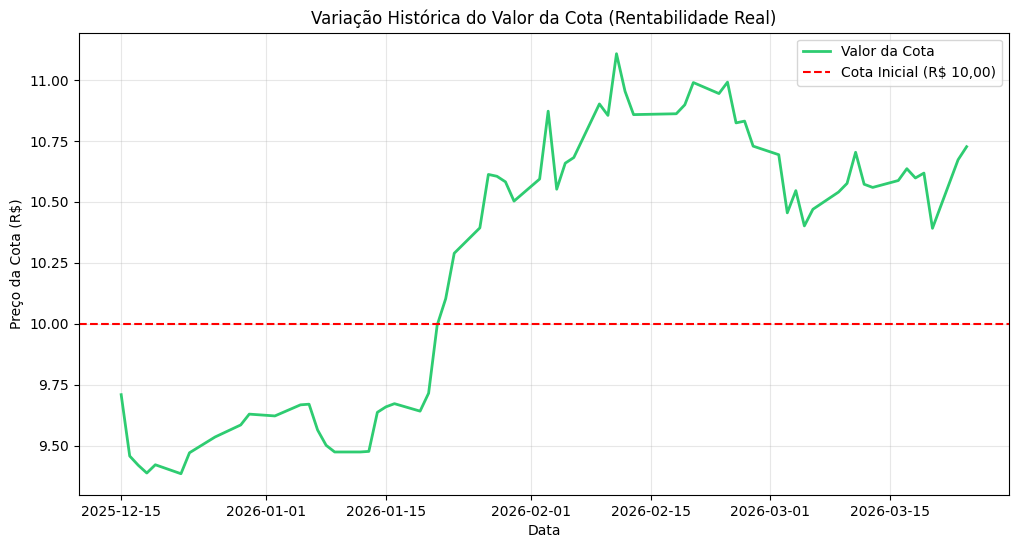

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --- Configurações Iniciais ---
data_inicial = pd.to_datetime("2025-12-15")
quantidade_cotas_ini = 44.581
data_hoje = pd.to_datetime(datetime.now().date())

# Movimentações (Modelo: "Data", "Ticker", Quantidade, Preço)
movimentacoes = [
    ("2025-12-15", "ITUB4.SA", 1, 40.14), ("2025-12-15", "ITSA4.SA", 2, 11.94),
    ("2025-12-15", "TAEE11.SA", 2, 42.99), ("2025-12-15", "PETR4.SA", 3, 31.91),
    ("2025-12-15", "RADL3.SA", 4, 25.34), ("2025-12-15", "WEGE3.SA", 2, 49.36),
    ("2026-01-15", "ITSA4.SA", 1, 12.09), ("2026-01-15", "TAEE11.SA", 1, 39.99),
    ("2026-01-15", "PETR4.SA", 1, 31.66), ("2026-01-15", "RADL3.SA", 2, 24.23),
    ("2026-01-15", "WEGE3.SA", 1, 46.85),
    ("2026-02-19", "TAEE11.SA", 1, 44.27), ("2026-02-19", "PETR4.SA", 1, 37.74),
    ("2026-02-19", "RADL3.SA", 1, 26.73), ("2026-02-19", "WEGE3.SA", 1, 51.62),
    ("2026-03-16", "ITUB4.SA", 5, 43.07), ("2026-03-16", "ITSA4.SA", 5, 13.42),
    ("2026-03-16", "BBSE3.SA", 3, 34.90), ("2026-03-16", "TAEE11.SA", -2, 42.77),
    ("2026-03-16", "PETR4.SA", -2, 45.50), ("2026-03-16", "WEGE3.SA", -2, 45.62),
    ("2026-03-17", "ITUB4.SA", -5, 42.97)
]

def gerar_grafico_cota(movs, data_alvo):
    df_movs = pd.DataFrame(movs, columns=['data', 'ticker', 'quant', 'preco'])
    df_movs['data'] = pd.to_datetime(df_movs['data'])
    tickers = df_movs['ticker'].unique()

    # Download de precos
    precos = yf.download(list(tickers), start="2025-12-15", end=data_alvo + timedelta(days=1))['Close']

    historico_cota = []
    cotas_atuais = quantidade_cotas_ini

    # Iterar por cada dia do histórico de preços
    for data in precos.index:
        # 1. Verificar se houve aporte/resgate NESTE dia para ajustar número de cotas
        movs_hoje = df_movs[df_movs['data'] == data]
        if not movs_hoje.empty and data > pd.to_datetime("2025-12-15"):
            # Para ajustar a cota, precisamos do patrimônio no fechamento anterior
            data_anterior = precos.index[precos.index < data][-1]
            precos_v_ontem = precos.loc[data_anterior]
            posicao_v_ontem = df_movs[df_movs['data'] < data].groupby('ticker')['quant'].sum()

            patrimonio_ontem = sum(posicao_v_ontem[t] * precos_v_ontem[t] for t in posicao_v_ontem.index if t in precos_v_ontem)
            v_cota_viva = patrimonio_ontem / cotas_atuais

            fluxo = (movs_hoje['quant'] * movs_hoje['preco']).sum()
            cotas_atuais += fluxo / v_cota_viva

        # 2. Calcular patrimônio do dia atual
        posicao_agora = df_movs[df_movs['data'] <= data].groupby('ticker')['quant'].sum()
        precos_hoje = precos.loc[data]
        patrimonio_hoje = sum(posicao_agora[t] * precos_hoje[t] for t in posicao_agora.index if t in precos_hoje)

        valor_cota_hoje = patrimonio_hoje / cotas_atuais
        historico_cota.append({'Data': data, 'Valor_Cota': valor_cota_hoje})

    df_grafico = pd.DataFrame(historico_cota).set_index('Data')

    # Plotagem
    plt.figure(figsize=(12, 6))
    plt.plot(df_grafico.index, df_grafico['Valor_Cota'], label='Valor da Cota', color='#2ecc71', linewidth=2)
    plt.axhline(y=10, color='red', linestyle='--', label='Cota Inicial (R$ 10,00)')
    plt.title('Variação Histórica do Valor da Cota (Rentabilidade Real)')
    plt.xlabel('Data')
    plt.ylabel('Preço da Cota (R$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Executar
gerar_grafico_cota(movimentacoes, data_hoje)

In [3]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# --- Configurações Iniciais ---
data_inicial = pd.to_datetime("2025-12-15")
quantidade_cotas_ini_A = 44.581
data_final = pd.to_datetime(datetime.now().date())

# --- MOVIMENTAÇÕES ---
# Marcador "A": Ativos do Investidor A
# Marcador "B": Ativos comprados com o dinheiro do Investidor B
movimentacoes = [
 ("2025-12-15", "ITUB4.SA", 1, 40.14, "Investidor A", "A"), ("2025-12-15", "ITSA4.SA", 2, 11.94, "Investidor A", "A"),
 ("2025-12-15", "TAEE11.SA", 2, 42.99, "Investidor A", "A"), ("2025-12-15", "PETR4.SA", 3, 31.91, "Investidor A", "A"),
 ("2025-12-15", "RADL3.SA", 4, 25.34, "Investidor A", "A"), ("2025-12-15", "WEGE3.SA", 2, 49.36, "Investidor A", "A"),

 # Bloco 2: Janeiro
 ("2026-01-15", "ITSA4.SA", 1, 12.09, "Investidor A", "A"), ("2026-01-15", "TAEE11.SA", 1, 39.99, "Investidor A", "A"),
 ("2026-01-15", "PETR4.SA", 1, 31.66, "Investidor A", "A"), ("2026-01-15", "RADL3.SA", 2, 24.23, "Investidor A", "A"),
 ("2026-01-15", "WEGE3.SA", 1, 46.85, "Investidor A", "A"),

 # Bloco 3: Fevereiro
 ("2026-02-19", "TAEE11.SA", 1, 44.27, "Investidor A", "A"), ("2026-02-19", "PETR4.SA", 1, 37.74, "Investidor A", "A"),
 ("2026-02-19", "RADL3.SA", 1, 26.73, "Investidor A", "A"), ("2026-02-19", "WEGE3.SA", 1, 51.62, "Investidor A", "A"),

 # Bloco 4: Março
 ("2026-03-16", "ITUB4.SA", 5, 43.07, "Investidor A", "A"), ("2026-03-16", "ITSA4.SA", 5, 13.42, "Investidor A", "A"),
 ("2026-03-16", "BBSE3.SA", 3, 34.90, "Investidor A", "A"), ("2026-03-16", "TAEE11.SA", -2, 42.77, "Investidor A", "A"),
 ("2026-03-16", "PETR4.SA", -2, 45.50, "Investidor A", "A"), ("2026-03-16", "WEGE3.SA", -2, 45.62, "Investidor A", "A"),
 ("2026-03-17", "ITUB4.SA", -5, 42.97, "Investidor A", "A"),

  # MARÇO: INVESTIDOR B APORTA DINHEIRO (R$ 5.000,00)
  # Este aporte define as COTAS iniciais de B baseadas no valor da cota de A no dia.
  ("2026-03-17", "APORTE", 4790.00, 1, "Investidor B", "B"),

  # MARÇO: INVESTIDOR A ALOCA O DINHEIRO DE B
  # Note o marcador "B": Isso diz ao sistema que essas ações NÃO são do Investidor A.
  ("2026-03-17", "BBSE3.SA", 100, 34.90, "Investidor A", "B"),
  ("2026-03-17", "VALE3.SA", 20, 65.00, "Investidor A", "B"),
]

def calcular_sistema_cota_unica(movs, data_alvo, cotas_ini_A):
    df = pd.DataFrame(movs, columns=['data', 'ticker', 'quant', 'preco', 'investidor', 'marcador'])
    df['data'] = pd.to_datetime(df['data'])

    tickers_reais = [t for t in df['ticker'].unique() if t != "APORTE"]
    precos = yf.download(tickers_reais, start="2025-12-15", end=(data_alvo + timedelta(days=1)).strftime('%Y-%m-%d'))['Close']

    if isinstance(precos, pd.Series): precos = precos.to_frame(name=tickers_reais[0])

    cotas_A = cotas_ini_A
    cotas_B = 0.0

    datas_eventos = sorted(df[df['data'] > "2025-12-15"]['data'].unique())

    for data_evento in datas_eventos:
        # 1. VALOR DA COTA DE A (Referência para todos)
        # Consideramos apenas o que é marcador "A" para ditar o preço da cota
        posicao_A = df[(df['data'] < data_evento) & (df['marcador'] == "A")].groupby('ticker')['quant'].sum()
        data_previa_idx = precos.index[precos.index < data_evento]
        if len(data_previa_idx) == 0: continue

        precos_v = precos.loc[data_previa_idx[-1]]
        patrimonio_A_antes = sum(posicao_A[t] * precos_v[t] for t in posicao_A.index if t in precos_v)
        valor_cota_unificada = patrimonio_A_antes / cotas_A

        # 2. Processar Aportes do Dia
        df_hoje = df[df['data'] == data_evento]

        # Aportes de B (Dinheiro novo)
        aportes_B = df_hoje[(df_hoje['investidor'] == "Investidor B") & (df_hoje['ticker'] == "APORTE")]['quant'].sum()
        if aportes_B > 0:
            cotas_B += aportes_B / valor_cota_unificada

        # Aportes de A (Novas compras marcadas como A)
        compras_A = df_hoje[df_hoje['marcador'] == "A"]
        fluxo_A = (compras_A['quant'] * compras_A['preco']).sum()
        if fluxo_A != 0:
            cotas_A += fluxo_A / valor_cota_unificada

    # --- FECHAMENTO FINAL ---
    precos_f = precos.iloc[-1]

    # Patrimônio Real de A (Ativos marcador A)
    pos_A = df[df['marcador'] == "A"].groupby('ticker')['quant'].sum()
    patrimonio_f_A = sum(pos_A[t] * precos_f[t] for t in pos_A.index if t in precos_f)
    valor_cota_final = patrimonio_f_A / cotas_A

    # Patrimônio de B (Baseado na cota de A)
    patrimonio_f_B = cotas_B * valor_cota_final

    return {
        "Data": precos.index[-1].date(),
        "Cota_Unificada": valor_cota_final,
        "A": {"Patrimonio": patrimonio_f_A, "Cotas": cotas_A},
        "B": {"Patrimonio": patrimonio_f_B, "Cotas": cotas_B}
    }

# --- Execução ---
res = calcular_sistema_cota_unica(movimentacoes, data_final, quantidade_cotas_ini_A)

print(f"\n--- RELATÓRIO DE COTA UNIFICADA (Ref: Investidor A) - {res['Data']} ---")
print(f"VALOR DA COTA ATUAL: {res['Cota_Unificada']:.4f}")
print("-" * 60)
print(f"INVESTIDOR A:")
print(f"  Cotas: {res['A']['Cotas']:.4f} | Patrimônio: R$ {res['A']['Patrimonio']:,.2f}")
print(f"\nINVESTIDOR B:")
print(f"  Cotas: {res['B']['Cotas']:.4f} | Patrimônio: R$ {res['B']['Patrimonio']:,.2f}")
print("-" * 60)
print(f"PATRIMÔNIO TOTAL GESTIONADO: R$ {res['A']['Patrimonio'] + res['B']['Patrimonio']:,.2f}")

/tmp/ipykernel_6531/3317741971.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(tickers_reais, start="2025-12-15", end=(data_alvo + timedelta(days=1)).strftime('%Y-%m-%d'))['Close']
[*********************100%***********************]  8 of 8 completed



--- RELATÓRIO DE COTA UNIFICADA (Ref: Investidor A) - 2026-03-27 ---
VALOR DA COTA ATUAL: 10.7484
------------------------------------------------------------
INVESTIDOR A:
  Cotas: 68.9377 | Patrimônio: R$ 740.97

INVESTIDOR B:
  Cotas: 452.4126 | Patrimônio: R$ 4,862.71
------------------------------------------------------------
PATRIMÔNIO TOTAL GESTIONADO: R$ 5,603.68


In [4]:
import math

# --- ESTRATÉGIA: VENDER O ATIVO VENCEDOR (ARREDONDADO PARA INTEIROS) ---

def gerar_ordem_venda_vencedor(movs, res_sistema, percentual=0.01):
    df_temp = pd.DataFrame(movs, columns=['data', 'ticker', 'quant', 'preco', 'investidor', 'marcador'])

    # Obtendo preços atuais (1d)
    tickers_reais = [t for t in df_temp['ticker'].unique() if t != "APORTE"]
    precos_finais = yf.download(tickers_reais, period="1d")['Close'].iloc[-1]

    print(f"\n{'='*60}")
    print(f"{'ORDENS DE VENDA - ESTRATÉGIA DE REALIZAÇÃO DE LUCRO':^60}")
    print(f"{'='*60}")

    for inv_label in ['A', 'B']:
        target_resgate = res_sistema[inv_label]['Patrimonio'] * percentual

        # 1. Calcular Performance dos ativos do marcador
        performance_ativos = []
        # Filter out 'APORTE' here as well, since it's not a real ticker with market price
        posicao_inv = df_temp[(df_temp['marcador'] == inv_label) & (df_temp['ticker'] != 'APORTE')].groupby('ticker')

        for ticker, grupo in posicao_inv:
            qtd_total = grupo['quant'].sum()
            if qtd_total <= 0: continue

            # Preço Médio
            compras = grupo[grupo['quant'] > 0]
            if compras.empty:
                # If there are no purchase transactions for this ticker, skip it
                continue
            preco_medio = (compras['quant'] * compras['preco']).sum() / compras['quant'].sum()

            preco_atual = precos_finais[ticker]
            valorizacao = (preco_atual / preco_medio) - 1

            performance_ativos.append({
                'ticker': ticker,
                'valorizacao': valorizacao,
                'preco_atual': preco_atual,
                'qtd_disponivel': qtd_total
            })

        if not performance_ativos:
            # If no actual tradable assets are found for the investor, skip to the next
            print(f"Investidor {inv_label} não possui ativos para venda ou não tem compras registradas.")
            continue

        # 2. Selecionar o Vencedor
        vencedor = max(performance_ativos, key=lambda x: x['valorizacao'])

        # 3. Arredondamento para Inteiro (Sempre para cima para garantir o 1%)
        qtd_inteira = math.ceil(target_resgate / vencedor['preco_atual'])
        valor_final_venda = qtd_inteira * vencedor['preco_atual']

        print(f"\nINVESTIDOR {inv_label}:")
        print(f"  Target de 1%: R$ {target_resgate:,.2f}")
        print(f"  Ativo Escolhido: {vencedor['ticker']} (Alta de {vencedor['valorizacao']:.2%})")
        print(f"  Preço Atual: R$ {vencedor['preco_atual']:,.2f}")
        print("-" * 30)
        print(f"  >>> EXECUTAR VENDA: {qtd_inteira} unidade(s) de {vencedor['ticker']}")
        print(f"  >>> VALOR A RECEBER: R$ {valor_final_venda:,.2f}")

        if qtd_inteira > vencedor['qtd_disponivel']:
            print(f"  ⚠️ ALERTA: Saldo insuficiente em {vencedor['ticker']} ({vencedor['qtd_disponivel']} disp.)")

    print(f"\n{'='*60}")

# Execução
gerar_ordem_venda_vencedor(movimentacoes, res)

/tmp/ipykernel_6531/2533441036.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos_finais = yf.download(tickers_reais, period="1d")['Close'].iloc[-1]
[*********************100%***********************]  8 of 8 completed


    ORDENS DE VENDA - ESTRATÉGIA DE REALIZAÇÃO DE LUCRO     

INVESTIDOR A:
  Target de 1%: R$ 7.41
  Ativo Escolhido: PETR4.SA (Alta de 48.34%)
  Preço Atual: R$ 48.99
------------------------------
  >>> EXECUTAR VENDA: 1 unidade(s) de PETR4.SA
  >>> VALOR A RECEBER: R$ 48.99

INVESTIDOR B:
  Target de 1%: R$ 48.63
  Ativo Escolhido: VALE3.SA (Alta de 22.05%)
  Preço Atual: R$ 79.33
------------------------------
  >>> EXECUTAR VENDA: 1 unidade(s) de VALE3.SA
  >>> VALOR A RECEBER: R$ 79.33

